In [137]:
# PROYECTO: Predicción de Riesgo de Mortalidad Materna (KDHS 2022)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
# Definición de la ruta
file_path = '/content/kdhs_2022_data_maternal_mortality.csv'

# Carga del dataset
df = pd.read_csv(file_path)

# Visualización de los datos cargados
display(df.head())

,county,age,parity,education,anc_visits,place_delivery,skilled_attendant,c_section,postnatal48h,marital_status,...,wealth_quintile,household_size,distance_facility,urbanization,health_facility_density,poverty_rate,sba_coverage,county_edu_index,hiv_prev,maternal_death
0,Bungoma,27,5,Secondary,3,Public,Skilled,0,1,Married,...,4,7,46,Rural,14.1,39.5,54.8,56.2,8.1,No
1,Isiolo,27,1,Higher,2,Public,Skilled,0,1,Married,...,3,4,38,Rural,10.0,36.2,62.0,66.5,2.6,No
2,Kitui,25,2,Secondary,6,Private,Skilled,0,1,Not in union,...,2,2,48,Rural,15.0,12.9,91.3,91.1,4.4,No
3,Kajiado,24,1,Primary,6,Public,Skilled,0,0,Married,...,1,6,37,Rural,13.4,58.2,75.9,79.3,8.4,No
4,Tana River,33,2,Primary,2,Private,Skilled,1,1,Not in union,...,5,6,30,Rural,3.2,45.2,99.3,93.8,5.3,No


In [138]:
#  Conversión variable objetivo

df['maternal_death'] = df['maternal_death'].map({'No': 0, 'Yes': 1})

# Verificar
print(df['maternal_death'].value_counts())
print(df['maternal_death'].dtype)

maternal_death
0    5394
1     606
Name: count, dtype: int64
int64


La variable objetivo fue transformada a formato numérico binario (0 = no fallece, 1 = fallece) para permitir su uso en modelos de aprendizaje automático y en análisis estadísticos.

Definición del Problema
Contexto: Según la Organización Mundial de la Salud (OMS), la mortalidad materna es un indicador crítico de la calidad de los sistemas de salud. La mayoría de estas muertes son prevenibles mediante intervenciones oportunas y un manejo adecuado. Este conjunto de datos se utiliza para predecir la probabilidad de que ocurra un evento de mortalidad materna en función de parámetros sociodemográficos, clínicos y de acceso a servicios de salud. Cada fila proporciona información relevante sobre una mujer en edad reproductiva.

Información de atributos:
-county: Condado administrativo de residencia.

-age: Edad de la mujer (15–49 años).

-parity: Número total de nacimientos vivos previos.

-education: Nivel de educación formal alcanzado.

-anc_visits: Número de visitas de atención prenatal realizadas.

-place_delivery: Lugar donde se atendió el parto (Hogar, Público, Privado).

-skilled_attendant: Indica si el parto fue asistido por personal cualificado.

-c_section: Indica si se realizó una cesárea (1: Sí, 0: No).

-postnatal48h: Indica si recibió atención postnatal en las primeras 48 horas.

-marital_status: Estado civil o de unión actual.

-age_first_birth: Edad al momento del primer parto.

-birth_interval: Meses transcurridos desde el nacimiento anterior.

-wealth_quintile: Situación socioeconómica del hogar (1 al 5).

-distance_facility: Distancia al centro de salud más cercano (km).

-urbanization: Tipo de residencia (Urbano o Rural).

-hiv_prev: Prevalencia de VIH en la región o individuo.

-maternal_death (Target): 1 si se produjo fallecimiento materno, 0 si no.

Información del DataSet preliminar.

In [139]:
# Visualización de los primeros 5 registros
df.head(5)

,county,age,parity,education,anc_visits,place_delivery,skilled_attendant,c_section,postnatal48h,marital_status,...,wealth_quintile,household_size,distance_facility,urbanization,health_facility_density,poverty_rate,sba_coverage,county_edu_index,hiv_prev,maternal_death
0,Bungoma,27,5,Secondary,3,Public,Skilled,0,1,Married,...,4,7,46,Rural,14.1,39.5,54.8,56.2,8.1,0
1,Isiolo,27,1,Higher,2,Public,Skilled,0,1,Married,...,3,4,38,Rural,10.0,36.2,62.0,66.5,2.6,0
2,Kitui,25,2,Secondary,6,Private,Skilled,0,1,Not in union,...,2,2,48,Rural,15.0,12.9,91.3,91.1,4.4,0
3,Kajiado,24,1,Primary,6,Public,Skilled,0,0,Married,...,1,6,37,Rural,13.4,58.2,75.9,79.3,8.4,0
4,Tana River,33,2,Primary,2,Private,Skilled,1,1,Not in union,...,5,6,30,Rural,3.2,45.2,99.3,93.8,5.3,0


In [140]:
# Dimensiones del conjunto de datos
df.shape

(6000, 22)

El DataSet contiene 22 atributos y 6000 registros.

In [141]:
# Visualización de 5 registros aleatorios (verificar consistencia)
df.sample(5)

,county,age,parity,education,anc_visits,place_delivery,skilled_attendant,c_section,postnatal48h,marital_status,...,wealth_quintile,household_size,distance_facility,urbanization,health_facility_density,poverty_rate,sba_coverage,county_edu_index,hiv_prev,maternal_death
4527,Uasin Gishu,27,1,Primary,5,Home,Not Skilled,0,1,Not in union,...,2,5,45,Rural,9.2,11.0,98.2,62.1,5.0,0
1115,Kirinyaga,33,4,NaN,4,Private,Not Skilled,0,1,Married,...,4,7,34,Rural,5.3,18.3,81.9,84.0,4.3,0
1786,Nandi,32,2,Primary,6,Home,Skilled,0,1,Not in union,...,3,6,16,Rural,3.5,22.5,65.9,87.6,2.2,0
5500,Elgeyo-Marakwet,27,9,NaN,2,Public,Skilled,1,1,Married,...,3,8,38,Rural,11.6,42.3,65.4,59.8,9.4,1
1934,Bungoma,31,1,Primary,3,Public,Skilled,0,1,Not in union,...,5,1,13,Rural,14.1,50.2,56.1,63.5,3.3,0


Revisar la cantidad de valores nulos del DataFrame.

In [142]:
# Revisar valores nulos y porcentaje
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df)) * 100

pd.DataFrame({
    'Valores nulos': nulls,
    'Porcentaje (%)': nulls_pct
}).sort_values(by='Valores nulos', ascending=False)

,Valores nulos,Porcentaje (%)
education,596,9.933333
county,0,0.000000
age,0,0.000000
parity,0,0.000000
anc_visits,0,0.000000
place_delivery,0,0.000000
skilled_attendant,0,0.000000
c_section,0,0.000000
postnatal48h,0,0.000000
marital_status,0,0.000000


El atributo education presenta 596 valores nulos o missing values, los cuales deberán ser tratados en la etapa de preprocesamiento.

Frecuencia de casos:
maternal_death
0    5394
1     606
Name: count, dtype: int64

Porcentaje de casos (%):
maternal_death
0    89.9
1    10.1
Name: proportion, dtype: float64


/tmp/ipykernel_18203/4041338320.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No fallece', 'Fallece'])


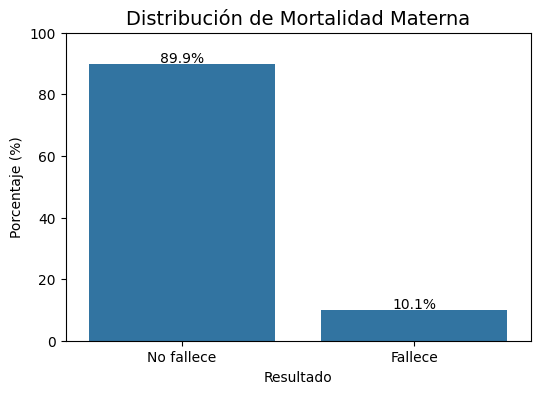


Distribución porcentual por nivel educativo:
maternal_death          0          1
education                           
Higher          94.476410   5.523590
Primary         88.079191  11.920809
Secondary       92.086997   7.913003


<Figure size 800x500 with 0 Axes>

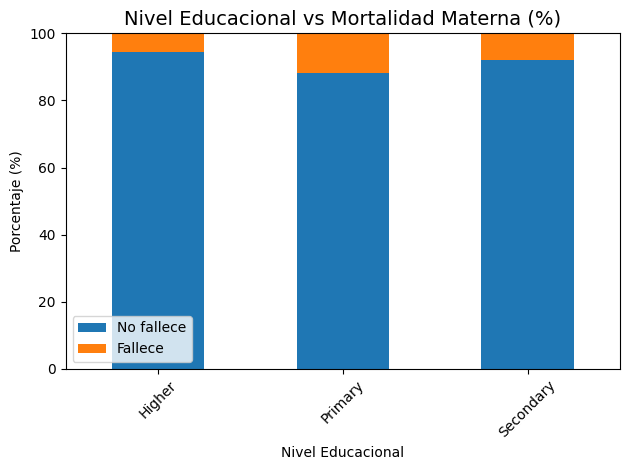

In [143]:
# Distribución variable objetivo


frecuencia = df['maternal_death'].value_counts()
porcentaje = df['maternal_death'].value_counts(normalize=True) * 100

print("Frecuencia de casos:")
print(frecuencia)

print("\nPorcentaje de casos (%):")
print(porcentaje)

# Gráfico
plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=porcentaje.index,
    y=porcentaje.values
)

plt.title('Distribución de Mortalidad Materna', fontsize=14)
plt.xlabel('Resultado')
plt.ylabel('Porcentaje (%)')

ax.set_xticklabels(['No fallece', 'Fallece'])

for i, v in enumerate(porcentaje.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.ylim(0, 100)
plt.show()


# Educación vs Mortalidad


tabla = pd.crosstab(df['education'], df['maternal_death'], normalize='index') * 100

print("\nDistribución porcentual por nivel educativo:")
print(tabla)

plt.figure(figsize=(8,5))

tabla.plot(
    kind='bar',
    stacked=True
)

plt.title('Nivel Educacional vs Mortalidad Materna (%)', fontsize=14)
plt.xlabel('Nivel Educacional')
plt.ylabel('Porcentaje (%)')
plt.legend(['No fallece', 'Fallece'])

plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

 A partir de las gráficas generadas, se pueden extraer las siguientes conclusiones preliminares sobre el comportamiento de los datos:

Distribución de la Variable Objetivo:

Se observa un claro desbalance de clases en la variable objetivo, donde aproximadamente el 89.9% de los casos corresponden a mujeres que no presentan mortalidad materna, mientras que solo un 10.1% corresponde a eventos de fallecimiento.

Este desbalance implica que la métrica de accuracy no es suficiente para evaluar el desempeño del modelo, siendo necesario incorporar métricas como recall, precisión y F1-score, que permitan evaluar adecuadamente la capacidad del modelo para detectar la clase minoritaria.

Relación entre Educación y Mortalidad:

Al analizar la distribución porcentual de mortalidad dentro de cada nivel educativo, se observa que la proporción de casos de mortalidad tiende a ser mayor en niveles educativos más bajos.

Este resultado sugiere que el nivel educacional podría actuar como un determinante social relevante en el riesgo de mortalidad materna, posiblemente asociado a factores como acceso a información, condiciones socioeconómicas y uso de servicios de salud.

--- Cantidad de registros por Zona ---
urbanization
Rural    4193
Urban    1807
Name: count, dtype: int64

--- Distribución porcentual por zona ---
maternal_death          0          1
urbanization                        
Rural           89.983306  10.016694
Urban           89.706696  10.293304


<Figure size 600x400 with 0 Axes>

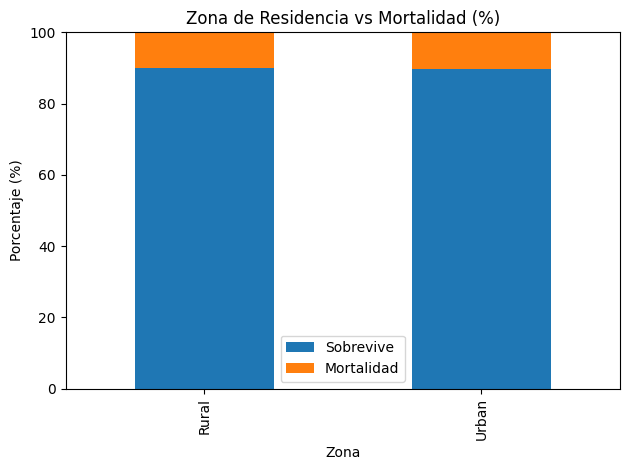

In [144]:
# Zona de residencia

print("--- Cantidad de registros por Zona ---")
print(df['urbanization'].value_counts())


#  Zona vs Mortalidad (PORCENTAJE)
tabla = pd.crosstab(df['urbanization'], df['maternal_death'], normalize='index') * 100

print("\n--- Distribución porcentual por zona ---")
print(tabla)


#  Gráfico

plt.figure(figsize=(6,4))

tabla.plot(
    kind='bar',
    stacked=True
)

plt.title('Zona de Residencia vs Mortalidad (%)')
plt.xlabel('Zona')
plt.ylabel('Porcentaje (%)')
plt.legend(['Sobrevive', 'Mortalidad'])

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

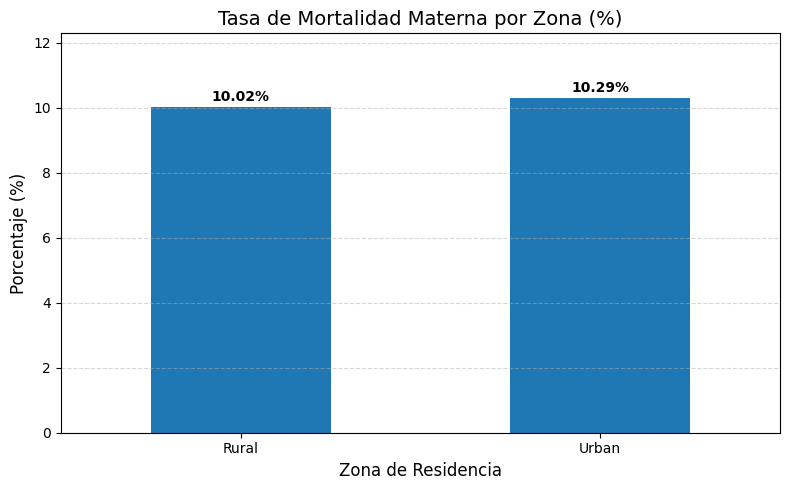

In [145]:
#  Tasa de mortalidad por zona (%)

tasa_mortalidad = df.groupby('urbanization')['maternal_death'].mean() * 100

plt.figure(figsize=(8, 5))

tasa_mortalidad.plot(kind='bar')

plt.title('Tasa de Mortalidad Materna por Zona (%)', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Zona de Residencia', fontsize=12)
plt.xticks(rotation=0)

# Mostrar valores
for i, v in enumerate(tasa_mortalidad):
    plt.text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')

plt.ylim(0, tasa_mortalidad.max() + 2)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Se analizó la relación entre la zona de residencia y la mortalidad materna utilizando proporciones dentro de cada categoría. Esto permitió identificar posibles diferencias en el riesgo entre zonas urbanas y rurales, evitando sesgos derivados del tamaño de la muestra en cada grupo.

El análisis de la tasa de mortalidad materna según zona de residencia muestra valores muy similares entre zonas rurales y urbanas, con una ligera mayor proporción en áreas urbanas (10.29%) en comparación con las rurales (10.02%).

Sin embargo, la diferencia observada es marginal, por lo que no se evidencia una relación clara o significativa entre la zona de residencia y el riesgo de mortalidad materna en esta etapa exploratoria.

Este resultado sugiere que otras variables, como el acceso efectivo a servicios de salud, condiciones socioeconómicas o factores clínicos, podrían tener un mayor peso en la explicación del fenómeno.

Cabe destacar que este análisis es de carácter exploratorio y no implica causalidad directa, por lo que los resultados deben ser validados mediante modelos predictivos posteriores.

In [146]:
#  Agrupación de paridad


bins_paridad = [-1, 2, 4, df['parity'].max()]
labels_paridad = ['1-2 Hijos', '3-4 Hijos', '5+ Hijos']

df['parity_group'] = pd.cut(
    df['parity'],
    bins=bins_paridad,
    labels=labels_paridad
)


# Conteo absoluto

conteo_paridad = df.groupby(['parity_group', 'maternal_death'], observed=False).size().unstack()

print("--- TABLA 1: CONTEO ABSOLUTO (PARIDAD) ---")
print(conteo_paridad)


# Tasa de mortalidad (%)

tasa_paridad = df.groupby('parity_group', observed=False)['maternal_death'].mean() * 100

print("\n--- TABLA 2: TASA DE RIESGO (%) ---")
print(tasa_paridad)

--- TABLA 1: CONTEO ABSOLUTO (PARIDAD) ---
maternal_death     0    1
parity_group             
1-2 Hijos       3791  366
3-4 Hijos       1346  182
5+ Hijos         257   58

--- TABLA 2: TASA DE RIESGO (%) ---
parity_group
1-2 Hijos     8.804426
3-4 Hijos    11.910995
5+ Hijos     18.412698
Name: maternal_death, dtype: float64


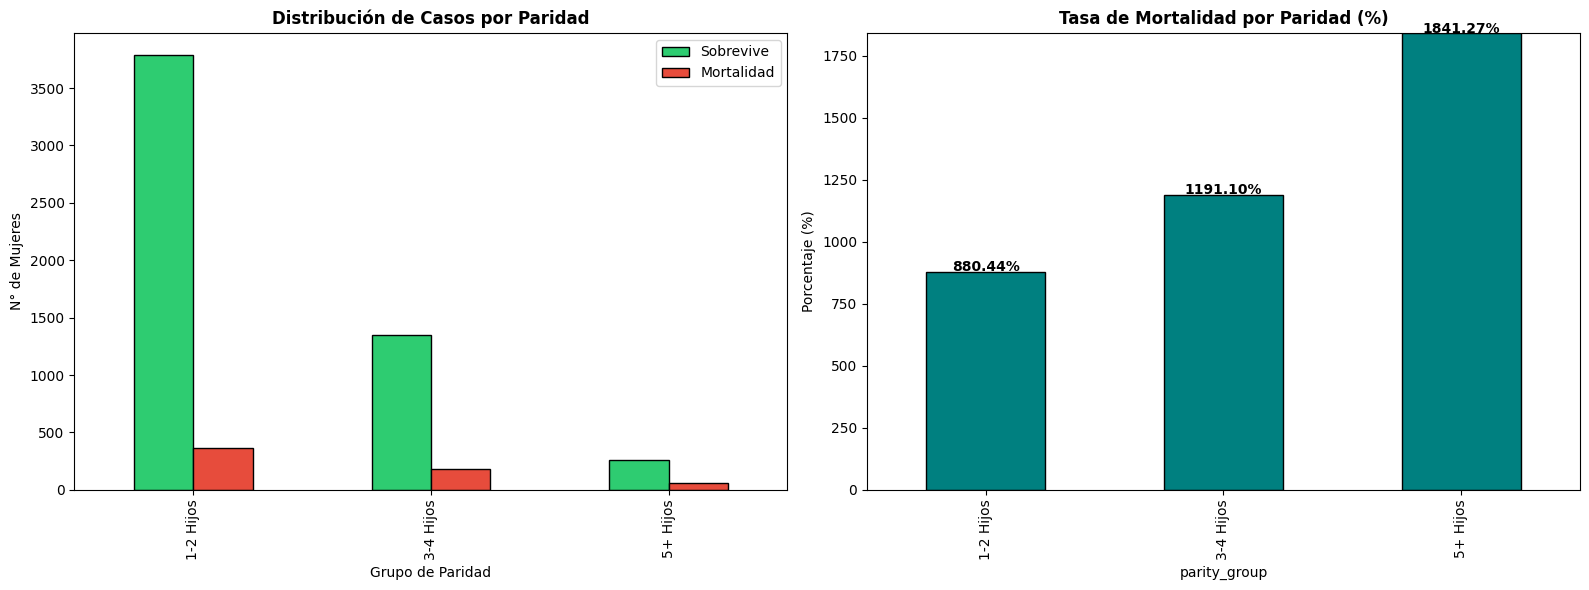

In [147]:
# Gráficos Paridad

fig, ax = plt.subplots(1, 2, figsize=(16, 6))


# A. Volumen

conteo_paridad.plot(
    kind='bar',
    ax=ax[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)

ax[0].set_title('Distribución de Casos por Paridad', fontweight='bold')
ax[0].set_ylabel('N° de Mujeres')
ax[0].set_xlabel('Grupo de Paridad')
ax[0].legend(['Sobrevive', 'Mortalidad'])



# B. Tasa de Mortalidad (%)

tasa_porcentaje = tasa_paridad * 100

tasa_porcentaje.plot(
    kind='bar',
    ax=ax[1],
    color='teal',
    edgecolor='black'
)

ax[1].set_title('Tasa de Mortalidad por Paridad (%)', fontweight='bold')
ax[1].set_ylabel('Porcentaje (%)')

# Etiquetas
for i, v in enumerate(tasa_porcentaje):
    ax[1].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')

ax[1].set_ylim(0, tasa_porcentaje.max() + 2)

plt.tight_layout()
plt.show()

Se analizaron tanto el volumen de casos como la tasa de mortalidad por grupo de paridad. Mientras que el conteo absoluto permite observar la distribución de la muestra, la tasa de mortalidad proporciona una medida más precisa del riesgo asociado a cada grupo.

Los resultados evidencian variaciones en el riesgo de mortalidad según el número de hijos, lo que sugiere que la paridad podría influir en la probabilidad de eventos adversos durante el embarazo.

No obstante, este análisis es exploratorio y no implica causalidad directa.

In [148]:

#  Agrupación de visitas prenatales (ANC)


bins_anc = [-1, 1, 3, df['anc_visits'].max()]
labels_anc = ['1 Visita', '2-3 Visitas', '4+ Visitas']

df['anc_group'] = pd.cut(
    df['anc_visits'],
    bins=bins_anc,
    labels=labels_anc
)

# Conteo absoluto

conteo_anc = df.groupby(['anc_group', 'maternal_death'], observed=False).size().unstack()

print("--- TABLA 1: CONTEO POR CLASIFICACIÓN ---")
print(conteo_anc)



# Tasa de mortalidad (%)


tasa_anc = df.groupby('anc_group', observed=False)['maternal_death'].mean() * 100

print("\n--- TABLA 2: RIESGO POR CLASIFICACIÓN (%) ---")
print(tasa_anc)

--- TABLA 1: CONTEO POR CLASIFICACIÓN ---
maternal_death     0    1
anc_group                
1 Visita         868  122
2-3 Visitas     1776  247
4+ Visitas      2750  237

--- TABLA 2: RIESGO POR CLASIFICACIÓN (%) ---
anc_group
1 Visita       12.323232
2-3 Visitas    12.209590
4+ Visitas      7.934382
Name: maternal_death, dtype: float64


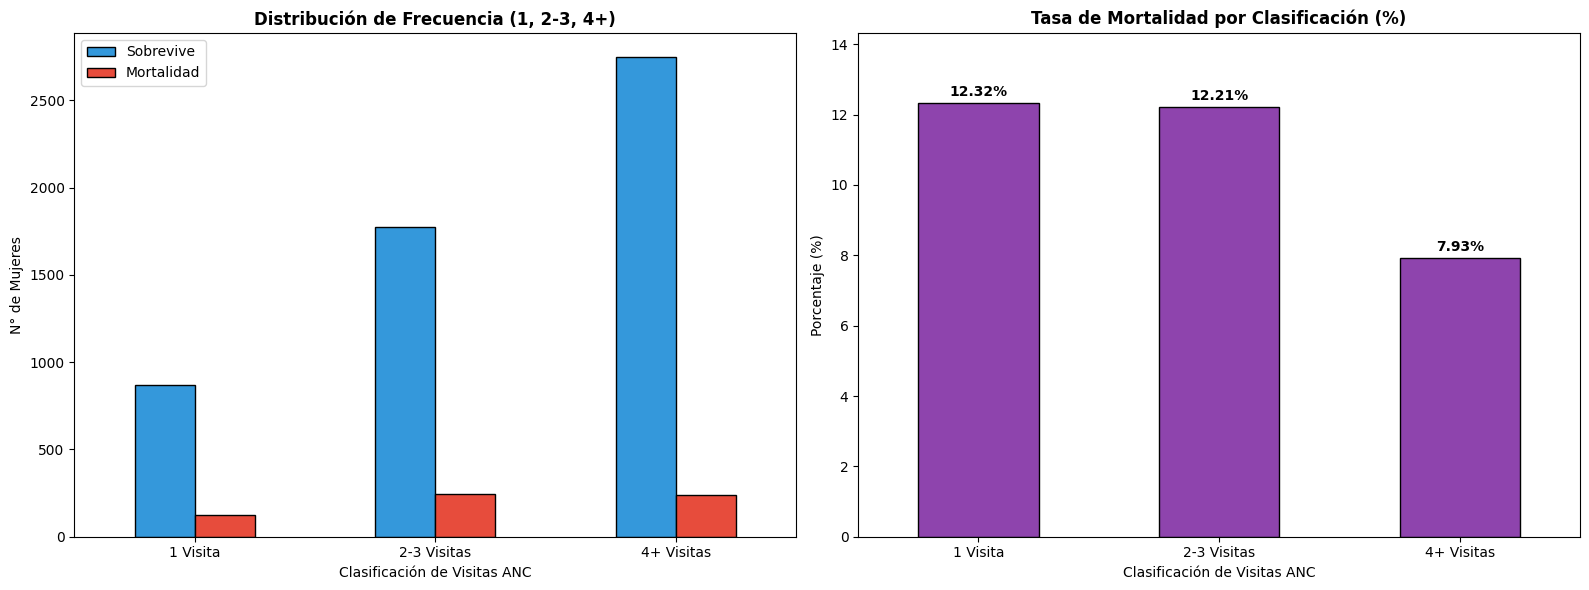

In [149]:
#  Gráficos ANC (mejorado)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))


# A. Distribución (OK)
conteo_anc.plot(
    kind='bar',
    ax=ax[0],
    color=['#3498db', '#e74c3c'],
    edgecolor='black'
)

ax[0].set_title('Distribución de Frecuencia (1, 2-3, 4+)', fontweight='bold')
ax[0].set_ylabel('N° de Mujeres')
ax[0].set_xlabel('Clasificación de Visitas ANC')
ax[0].legend(['Sobrevive', 'Mortalidad'])
ax[0].tick_params(axis='x', rotation=0)



# B. Riesgo en porcentaje
tasa_porcentaje = tasa_anc

tasa_porcentaje.plot(
    kind='bar',
    ax=ax[1],
    color='#8e44ad',
    edgecolor='black'
)

ax[1].set_title('Tasa de Mortalidad por Clasificación (%)', fontweight='bold')
ax[1].set_ylabel('Porcentaje (%)')
ax[1].set_xlabel('Clasificación de Visitas ANC')
ax[1].tick_params(axis='x', rotation=0)

# Etiquetas
for i, v in enumerate(tasa_porcentaje):
    if not pd.isna(v):
        ax[1].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')

ax[1].set_ylim(0, tasa_porcentaje.max() + 2)

plt.tight_layout()
plt.show()

Se analizaron tanto la distribución de la muestra como la tasa de mortalidad según la frecuencia de visitas prenatales. Mientras que el conteo absoluto permite observar la composición de los datos, la tasa de mortalidad proporciona una medida más adecuada del riesgo.

Los resultados sugieren que el número de controles prenatales podría estar asociado al riesgo de mortalidad materna, lo que refuerza la importancia del seguimiento clínico durante el embarazo como factor potencialmente protector.

No obstante, este análisis es exploratorio y no implica causalidad directa.

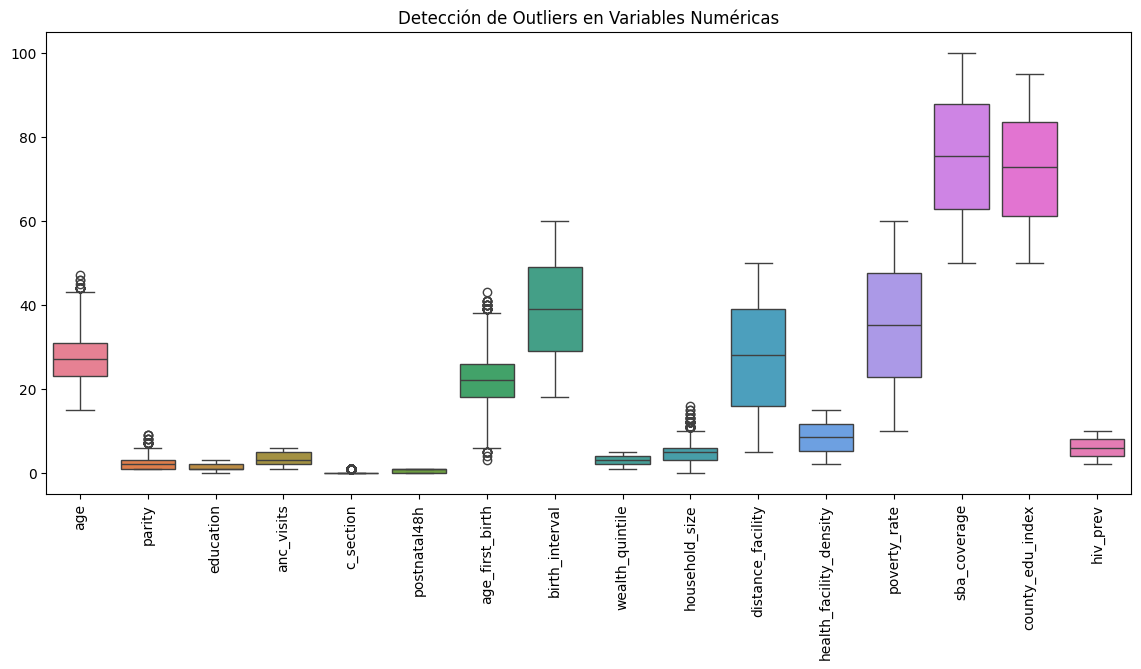

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo variables numéricas
num_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns

# (opcional) excluir la variable objetivo para que no distorsione el gráfico
num_cols = num_cols.drop('maternal_death')

plt.figure(figsize=(14,6))
sns.boxplot(data=df_encoded[num_cols])

plt.xticks(rotation=90)
plt.title("Detección de Outliers en Variables Numéricas")
plt.show()

El gráfico muestra la distribución de las variables numéricas y la presencia de valores atípicos en varias de ellas. Se observa que algunas variables presentan alta dispersión y asimetría, con puntos alejados del rango central. Estos outliers pueden corresponder a casos extremos relevantes del contexto de salud, por lo que no necesariamente representan errores y deben ser considerados en el análisis.

Tras el análisis exploratorio de las variables clave (paridad, controles prenatales, nivel educativo y zona de residencia), se identifican patrones relevantes en la distribución del riesgo de mortalidad materna.

En primer lugar, se observa un fuerte desbalance de clases, donde aproximadamente el 10% de los casos corresponde a mortalidad materna. Esto implica que métricas como accuracy pueden ser engañosas, siendo necesario utilizar indicadores como recall, F1-score o AUC en etapas posteriores.

En relación con los factores analizados, se identifican asociaciones descriptivas entre el acceso a servicios de salud y el riesgo observado. En particular, los grupos con menor número de controles prenatales presentan mayores tasas relativas de mortalidad, lo que sugiere una posible relación entre seguimiento médico y resultados maternos.

Asimismo, variables como el nivel educativo y la paridad muestran patrones diferenciados en la distribución de casos, lo que indica su potencial valor predictivo dentro del modelo.

Por otro lado, se detectan limitaciones en la calidad de los datos, incluyendo:

Posible presencia de valores ambiguos o inconsistentes en variables categóricas como educación.
Ausencia de ciertos grupos relevantes (por ejemplo, casos sin controles prenatales), lo que podría introducir sesgos en el análisis.

En la siguiente fase, se realizará un proceso de preprocesamiento de datos, incluyendo:

Codificación de variables categóricas
Tratamiento de valores inconsistentes
Balanceo de clases

Esto permitirá construir un dataset más robusto para el entrenamiento de modelos de aprendizaje automático.

In [151]:
df.isnull().sum()

,0
county,0
age,0
parity,0
education,596
anc_visits,0
place_delivery,0
skilled_attendant,0
c_section,0
postnatal48h,0
marital_status,0


In [152]:
# LIMPIEZA GENERAL DE NULOS


# Variables categóricas
categoricas = df.select_dtypes(include='object').columns

for col in categoricas:
    df[col] = df[col].fillna('Desconocido')

# Variables numéricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns

for col in numericas:
    df[col] = df[col].fillna(df[col].median())

# Verificar nuevamente
print("Nulos después de limpieza:")
print(df.isnull().sum().sum())

Nulos después de limpieza:
0


In [153]:
df.isnull().sum()

,0
county,0
age,0
parity,0
education,0
anc_visits,0
place_delivery,0
skilled_attendant,0
c_section,0
postnatal48h,0
marital_status,0


Se realizó un análisis de completitud del dataset, identificando la presencia de valores nulos en diversas variables.

Para abordar esta problemática, se aplicaron estrategias diferenciadas según el tipo de dato:

En variables categóricas, los valores faltantes fueron reemplazados por la categoría "Desconocido", con el fin de preservar la información sin introducir supuestos.
En variables numéricas, los valores nulos fueron imputados utilizando la mediana, debido a su robustez frente a valores atípicos.

Este proceso permitió asegurar la calidad y consistencia de los datos, eliminando valores faltantes antes del entrenamiento de los modelos de aprendizaje automático.

In [154]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# VARIABLES ORDINALES
# Mapeo ordinal explícito
education_map = {
    'No education': 0,
    'Primary': 1,
    'Secondary': 2,
    'Higher': 3
}

df['education'] = df['education'].map(education_map)


# VARIABLES NOMINALES

nominal_vars = [
    'marital_status',
    'urbanization',
    'county',
    'place_delivery',
    'skilled_attendant'
]

df_encoded = pd.get_dummies(df, columns=nominal_vars, drop_first=True)

Para el proceso de transformación de variables categóricas a formato numérico, se aplicaron técnicas diferenciadas según la naturaleza de cada variable.

En el caso de la variable education, al presentar un orden lógico inherente, se utilizó Label Encoding, permitiendo representar sus categorías mediante valores numéricos ordinales.

Por otro lado, las variables marital_status, urbanization, county, place_delivery y skilled_attendant fueron tratadas como variables nominales, ya que no poseen un orden jerárquico. Para estas, se aplicó One-Hot Encoding mediante la función pd.get_dummies, generando variables binarias (0/1) y evitando problemas de multicolinealidad mediante el parámetro drop_first=True.

Este proceso permitió transformar adecuadamente todas las variables categóricas en formato numérico, cumpliendo con los requisitos necesarios para el entrenamiento de modelos de aprendizaje automático.

In [155]:
df_encoded.dtypes

,0
age,int64
parity,int64
education,float64
anc_visits,int64
c_section,int64
...,...
county_Wajir,bool
county_West Pokot,bool
place_delivery_Private,bool
place_delivery_Public,bool


In [156]:

# TRATAMIENTO DE NULOS

# Imputación para variables numéricas (
df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))

# Verificación
print("Nulos restantes:")
print(df_encoded.isnull().sum().sum())

Nulos restantes:
0


In [157]:
# TRATAMIENTO DE NULOS


# Imputación para variables numéricas
df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))

# Verificación
print("Nulos restantes:")
print(df_encoded.isnull().sum().sum())

Nulos restantes:
0


In [158]:
# DEFINICIÓN DE VARIABLES


# Variable objetivo
y = df_encoded['maternal_death']

# Variables predictoras
X = df_encoded.drop(columns=['maternal_death'])

# Eliminar variables derivadas si existen
cols_to_drop = ['maternal_death_int', 'age_group', 'parity_group']
X = X.drop(columns=cols_to_drop, errors='ignore')

# Verificación
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# Balance de clases
print("\nDistribución de la variable objetivo (%):")
print(y.value_counts(normalize=True) * 100)

Shape de X: (6000, 68)
Shape de y: (6000,)

Distribución de la variable objetivo (%):
maternal_death
0    89.9
1    10.1
Name: proportion, dtype: float64


In [159]:
corr = df_encoded.corr(numeric_only=True)['maternal_death'].sort_values(ascending=False)
print(corr.head(10))

maternal_death       1.000000
poverty_rate         0.105805
parity               0.084937
county_West Pokot    0.073675
county_Marsabit      0.069754
age                  0.063829
county_Tana River    0.058151
age_first_birth      0.057925
county_Turkana       0.057540
distance_facility    0.055192
Name: maternal_death, dtype: float64


El análisis de correlación mostró relaciones individuales débiles entre las variables predictoras y la variable objetivo. Este resultado sugiere que la predicción de la mortalidad materna no se explica por relaciones lineales simples, sino que probablemente depende de interacciones complejas y posibles efectos no lineales entre múltiples factores socioeconómicos, demográficos y de acceso a salud.

TRAIN / TEST SPLIT

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4800, 68)
Test: (1200, 68)


BALANCEADO

In [161]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [162]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [163]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [164]:
print("Antes de SMOTE:")
print(y_train.value_counts())

print("\nDespués de SMOTE:")
print(y_train_sm.value_counts())

Antes de SMOTE:
maternal_death
0    4315
1     485
Name: count, dtype: int64

Después de SMOTE:
maternal_death
0    4315
1    4315
Name: count, dtype: int64


ESCALADO

In [165]:
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [166]:
print(X_train.dtypes.value_counts())
print(X_train.head())

bool       53
int64      10
float64     6
Name: count, dtype: int64
      age  parity  education  anc_visits  c_section  postnatal48h  \
3776   21       1        1.0           6          0             1   
4903   25       2        1.0           4          0             1   
1881   27       2        2.0           6          0             0   
821    31       2        3.0           4          0             0   
3044   22       1        1.0           3          0             1   

      age_first_birth  birth_interval  wealth_quintile  household_size  ...  \
3776               13              23                1               0  ...   
4903               19              25                4               7  ...   
1881               23              40                2               7  ...   
821                27              55                1               3  ...   
3044               13              25                5               4  ...   

      county_Turkana  county_Uasin Gishu  

In [167]:
# convertir todo a numérico
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# eliminar NaN (importante)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# convertir bool a int explícito (seguridad extra)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [168]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

REESTABLECIMIENTO DEL ENTORNO DE EJECUCION

In [169]:
%reset -f

In [170]:
import pandas as pd

df = pd.read_csv('/content/kdhs_2022_data_maternal_mortality.csv')

In [171]:
df['maternal_death'] = df['maternal_death'].map({'No': 0, 'Yes': 1})

In [172]:
from sklearn.preprocessing import LabelEncoder

ordinal_vars = ['education']

for col in ordinal_vars:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

nominal_vars = [
    'marital_status','urbanization','county',
    'place_delivery','skilled_attendant'
]

df_encoded = pd.get_dummies(df, columns=nominal_vars, drop_first=True)

In [173]:
df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce')
df_encoded = df_encoded.fillna(0)

In [174]:
X = df_encoded.drop(columns=['maternal_death'])
y = df_encoded['maternal_death']

In [175]:
X = df_encoded.drop(columns=['maternal_death'])
y = df_encoded['maternal_death']

In [176]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [177]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

Durante el desarrollo del modelo fue necesario reiniciar el entorno de ejecución (%reset -f) debido a inconsistencias generadas en las variables del pipeline, producto de múltiples transformaciones aplicadas en distintas etapas del análisis (codificación, balanceo y escalado).

Este reinicio permitió limpiar el estado de memoria y evitar conflictos entre versiones previas de los datos, asegurando una reconstrucción ordenada del flujo de trabajo.

MODELO!-REGRESION LOGISTICA

In [178]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train_sm)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

MODELO 2 — RANDOM FOREST

In [179]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_sm, y_train_sm)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

MODELO 3 — GRADIENT BOOSTING

In [180]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_sm, y_train_sm)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

MODELO4 - DEEP LEARNING (RED NEURONAL SIMPLE EN KERAS)

In [181]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report

# Modelo de red neuronal
dl_model = Sequential()

# Capa de entrada + primera capa oculta
dl_model.add(Dense(32, activation='relu', input_shape=(X_train_sm.shape[1],)))

# Segunda capa oculta
dl_model.add(Dense(16, activation='relu'))

# Capa de salida (clasificación binaria)
dl_model.add(Dense(1, activation='sigmoid'))

# Compilar modelo
dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenar modelo
history = dl_model.fit(
    X_train_sm,
    y_train_sm,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Predicciones
y_pred_dl = (dl_model.predict(X_test) > 0.5).astype(int)

# Evaluación
print(classification_report(y_test, y_pred_dl))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6133 - loss: 0.6843 - val_accuracy: 0.4287 - val_loss: 0.7742
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6979 - loss: 0.5696 - val_accuracy: 0.7822 - val_loss: 0.5406
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7510 - loss: 0.5168 - val_accuracy: 0.5823 - val_loss: 0.7097
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7711 - loss: 0.4889 - val_accuracy: 0.6756 - val_loss: 0.6066
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7961 - loss: 0.4583 - val_accuracy: 0.7549 - val_loss: 0.5183
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8071 - loss: 0.4355 - val_accuracy: 0.6553 - val_loss: 0.6358
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8123 - loss: 0.4319 - val_accuracy: 0.7532 - val_loss: 0.5213
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8220 - loss: 0.4064 - val_accuracy: 0.9612 - val_

In [182]:
# Probabilidades
y_prob_dl = dl_model.predict(X_test).ravel()

# Predicción binaria
y_pred_dl = (y_prob_dl > 0.5).astype(int)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


EVALUACIÓN

In [183]:
from sklearn.metrics import classification_report, roc_auc_score

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_log))
auc_log = roc_auc_score(y_test, y_prob_log)
print("AUC:", auc_log)

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
auc_rf = roc_auc_score(y_test, y_prob_rf)
print("AUC:", auc_rf)

print("\n=== GRADIENT BOOSTING ===")
print(classification_report(y_test, y_pred_gb))
auc_gb = roc_auc_score(y_test, y_prob_gb)
print("AUC:", auc_gb)

print("\n=== DEEP LEARNING (MLP) ===")
print(classification_report(y_test, y_pred_dl))
auc_dl = roc_auc_score(y_test, y_prob_dl)
print("AUC:", auc_dl)

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1079
           1       0.33      0.07      0.12       121

    accuracy                           0.89      1200
   macro avg       0.62      0.53      0.53      1200
weighted avg       0.85      0.89      0.86      1200

AUC: 0.6341117808806747

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1079
           1       0.19      0.12      0.15       121

    accuracy                           0.86      1200
   macro avg       0.55      0.53      0.54      1200
weighted avg       0.83      0.86      0.84      1200

AUC: 0.6112140871177016

=== GRADIENT BOOSTING ===
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1079
           1       0.19      0.28      0.23       121

    accuracy                           0.81      1200
  

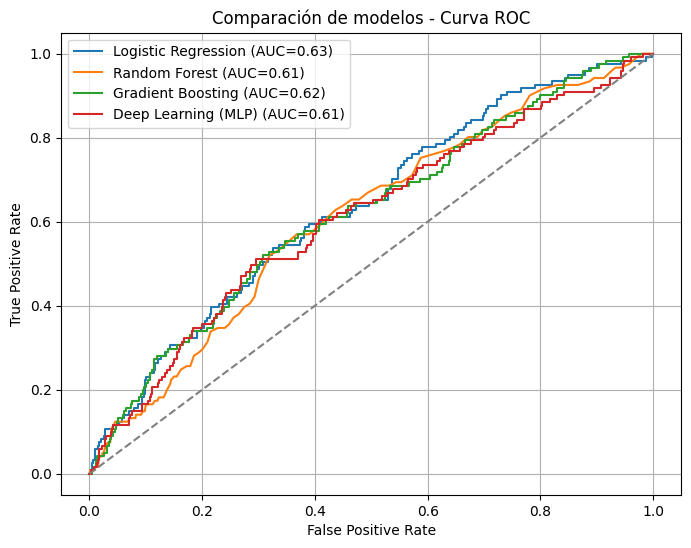

In [184]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

models = [
    ("Logistic Regression", y_prob_log),
    ("Random Forest", y_prob_rf),
    ("Gradient Boosting", y_prob_gb),
    ("Deep Learning (MLP)", y_prob_dl)
]

for name, prob in models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.title("Comparación de modelos - Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [185]:
import pandas as pd
from sklearn.metrics import roc_auc_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Deep Learning (MLP)"
    ],
    "AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_dl)
    ]
})

results.sort_values(by="AUC", ascending=False)

,Model,AUC
0,Logistic Regression,0.634112
2,Gradient Boosting,0.620149
1,Random Forest,0.611214
3,Deep Learning (MLP),0.609609


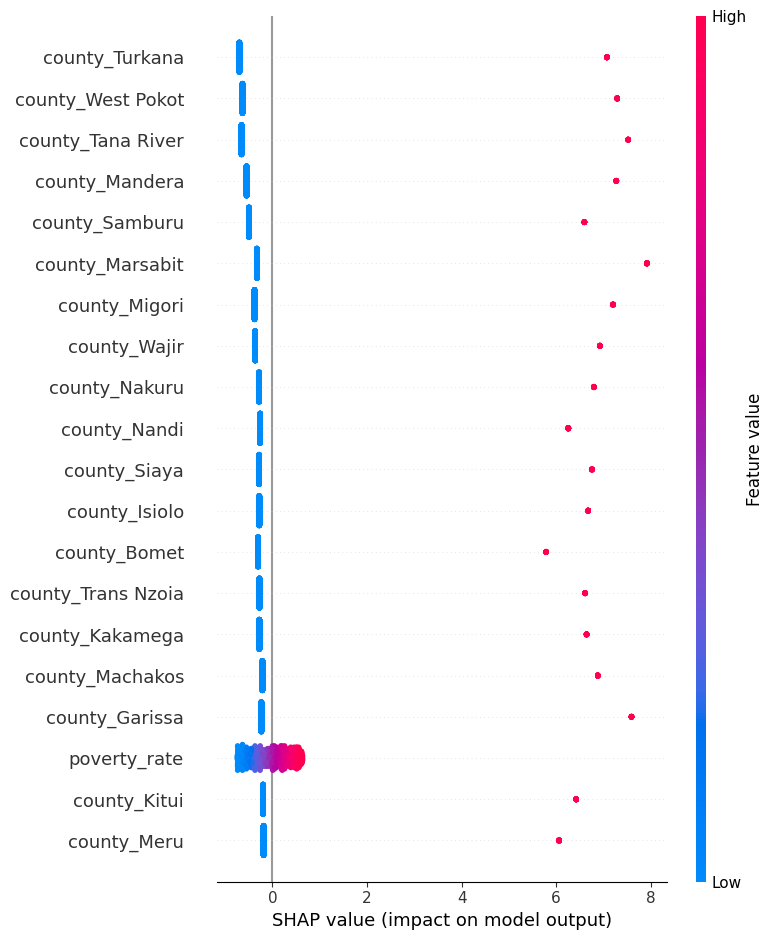

In [197]:
import shap

explainer = shap.Explainer(log_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.summary_plot(
    shap_values.values,
    X_test_scaled,
    feature_names=X_train.columns
)

Debido a la codificación one-hot de variables categóricas, SHAP muestra la contribución de cada categoría individual, lo que permite desagregar por ejemplo el impacto de cada región en la predicción.

El análisis comparativo muestra un desempeño moderado en la predicción de mortalidad materna, lo cual es consistente con la baja correlación observada entre las variables y la complejidad del problema.

La regresión logística obtuvo el mejor resultado (AUC = 0.63), seguida por Gradient Boosting (0.62) y Random Forest (0.61). Las diferencias son pequeñas, lo que indica que ningún modelo logra una mejora significativa sobre los demás.

Esto sugiere que el problema presenta baja separabilidad entre clases y relaciones débiles entre variables, lo que limita el desempeño de todos los enfoques evaluados. Además, el desbalance de clases influye negativamente en la capacidad de los modelos para detectar correctamente los casos de mortalidad.

En conclusión, el rendimiento está más condicionado por la calidad y estructura de los datos que por el tipo de modelo utilizado.